## 01_data_check: fasta to csv

In [2]:
from pathlib import Path

def read_fasta(file_path, label):
    sequences = []
    
    with open(file_path, 'r') as f:
        seq = ''
        for line in f:
            line = line.strip()
            
            if line.startswith('>'):
                if seq != '':
                    sequences.append((seq, label))
                    seq = ''
            else:
                seq += line
        
        # 最后一条
        if seq != '':
            sequences.append((seq, label))
    
    return sequences

In [3]:
train_pos_path = r"D:\360Downloads\bioinformatics\Task\AIP\data\training\pos_1365_train.fasta"
train_neg_path = r"D:\360Downloads\bioinformatics\Task\AIP\data\training\neg_2218_train.fasta"

test_pos_path = r"D:\360Downloads\bioinformatics\Task\AIP\data\test\pos_342_test.fasta"
test_neg_path = r"D:\360Downloads\bioinformatics\Task\AIP\data\test\neg_555_test.fasta"

In [4]:
train_pos = read_fasta(train_pos_path, 1)
train_neg = read_fasta(train_neg_path, 0)

test_pos = read_fasta(test_pos_path, 1)
test_neg = read_fasta(test_neg_path, 0)

In [5]:
import pandas as pd

train_data = pd.DataFrame(train_pos + train_neg, columns=['sequence', 'label'])
test_data = pd.DataFrame(test_pos + test_neg, columns=['sequence', 'label'])

In [6]:
#（1）检查序列size

print("Train size:", train_data.shape)
print("Test size:", test_data.shape)

print(train_data['label'].value_counts())
print(test_data['label'].value_counts())

Train size: (3583, 2)
Test size: (897, 2)
label
0    2218
1    1365
Name: count, dtype: int64
label
0    555
1    342
Name: count, dtype: int64


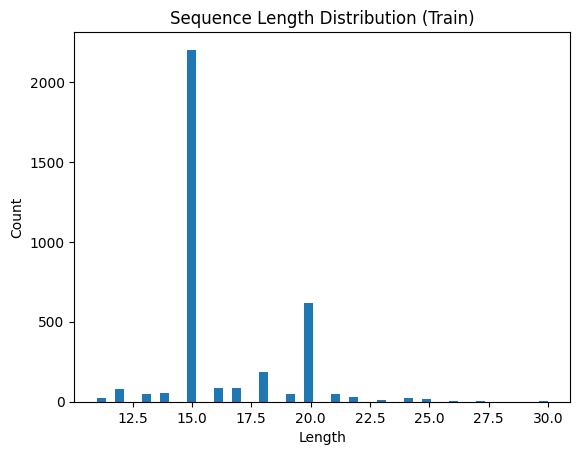

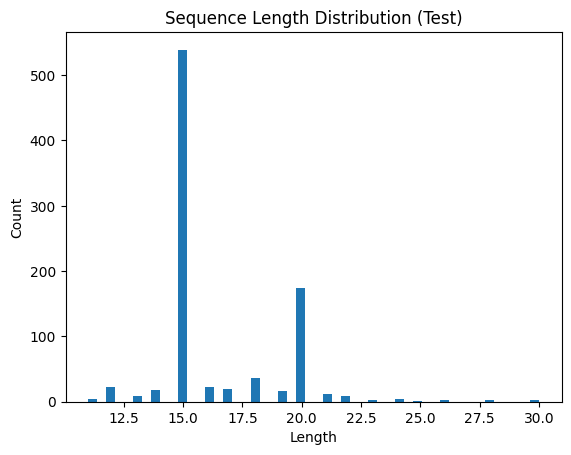

In [10]:
#（2）检查序列长度分布
train_data['length'] = train_data['sequence'].apply(len)
train_data['length'].describe()

test_data['length'] = test_data['sequence'].apply(len)
test_data['length'].describe()

import matplotlib.pyplot as plt
plt.hist(train_data['length'], bins=50)
plt.title("Sequence Length Distribution (Train)")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

plt.hist(test_data['length'], bins=50)
plt.title("Sequence Length Distribution (Test)")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

In [ ]:
#（3）检查标准氨基酸，只有20个
# 如果输出为0就证明只有标准氨基酸
valid_aa = set("ACDEFGHIKLMNPQRSTVWY")

def check_invalid(seq):
    return any(c not in valid_aa for c in seq)

train_data['invalid'] = train_data['sequence'].apply(check_invalid)

train_data['invalid'].sum()

0

In [ ]:
# 保存转化后的csv文件
import os

os.makedirs("D:/360Downloads/bioinformatics/Task/AIP/data/processed", exist_ok=True)

train_data[['sequence', 'label']].to_csv("D:/360Downloads/bioinformatics/Task/AIP/data/processed/train.csv", index=False)
test_data[['sequence', 'label']].to_csv("D:/360Downloads/bioinformatics/Task/AIP/data/processed/test.csv", index=False)